# Møller vortex packets — analysis workspace

This notebook is intended for day-to-day calculations based on the local `moller_vortex` package.

Use it for parameter scans, quick checks, plots, and comparisons between analytic and numerical expressions. The implementation itself lives in `src/moller_vortex/`; built-in check functions live in `src/moller_vortex/checks.py`; the detailed function guide is in `docs/FUNCTION_GUIDE.md`.


## 1. Imports and local package path

The cell below makes the local `src/` directory importable when the notebook is run from the project root. If the package has been installed with `pip install -e .`, this path setup is harmless.

In [1]:
import numpy as np
import moller_vortex as mv
import matplotlib.pyplot as plt
from dataclasses import replace

## 2. Numerical accuracy

All adaptive integrations use a `NumericalAccuracy` object. Keep accuracy parameters explicit in scans so that numerical settings are reproducible.

In [2]:
accuracy = mv.NumericalAccuracy(
    quad_epsabs=1.0e-16,
    quad_epsrel=1.0e-16,
    quad_limit= 50,
    root_residual_atol=1.0e-10,
)

accuracy


NumericalAccuracy(quad_epsabs=1e-16, quad_epsrel=1e-16, quad_limit=50, root_residual_atol=1e-10)

## 2.1 Built-in consistency checks

Run these when you want to check that the main analytic and numerical pieces still agree. They are ordinary functions, not a separate pytest suite.


In [3]:
check_results = mv.run_all_checks(
    accuracy=accuracy,
    n_phi=50,
    verbose=True,
)

C:\Users\User\Documents\moller_vortex\src\moller_vortex\packets.py:90: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = quad(
C:\Users\User\Documents\moller_vortex\src\moller_vortex\transverse.py:311: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  real_part = quad(
C:\Users\User\Documents\moller_vortex\src\moller_vortex\transverse.py:320: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  imag_part = quad(


Normalization errors
  spherical normalization, ell=0                0.000000e+00
  spherical normalization, ell=2                1.432532e-16
  spherical normalization, ell=-3               1.978304e-16
Laguerre-derivative errors
  Laguerre derivative, a=0, b=0                 0.000000e+00
  Laguerre derivative, a=0, b=3                 0.000000e+00
  Laguerre derivative, a=3, b=0                 0.000000e+00
  Laguerre derivative, a=1, b=4                 2.601311e-17
  Laguerre derivative, a=4, b=1                 6.462988e-17
  Laguerre derivative, a=3, b=3                 1.330882e-16
Transverse-integral errors
  transverse integral, ell1=1, ell2=2           1.091524e-14
  transverse integral, ell1=-1, ell2=-2         3.407029e-15
  transverse integral, ell1=1, ell2=-2          7.999396e-16
  transverse integral, ell1=-1, ell2=2          3.904939e-16
  transverse integral, ell1=0, ell2=2           4.325398e-16
  transverse integral, ell1=0, ell2=-2          1.060641e-15
  transver

Number of integration points check, normalization

C:\Users\User\Documents\moller_vortex\src\moller_vortex\packets.py:90: IntegrationWarning: The maximum number of subdivisions (1) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = quad(
C:\Users\User\Documents\moller_vortex\src\moller_vortex\packets.py:90: IntegrationWarning: The maximum number of subdivisions (2) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
 

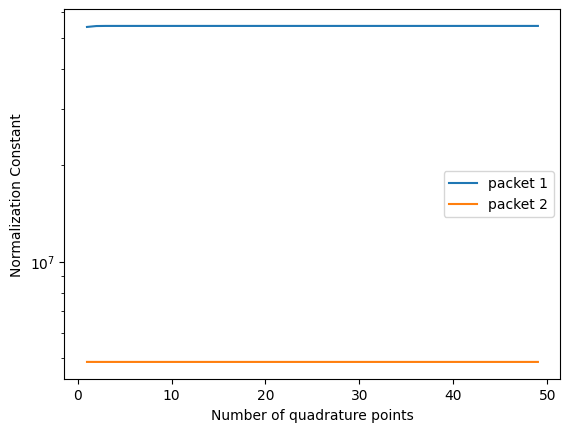

In [3]:
HBARC_MEV_NM = 1.97463e-4 #MeV * nm
NM_TO_MEV_INV = 1.0 / HBARC_MEV_NM 

def spatial_width_nm_to_momentum_mev(width_nm: float) -> float:
    return HBARC_MEV_NM / width_nm


sigma1_perp = spatial_width_nm_to_momentum_mev(10.0)
sigma2_perp = spatial_width_nm_to_momentum_mev(2.0)
sigma1_par = spatial_width_nm_to_momentum_mev(5.0)
sigma2_par = spatial_width_nm_to_momentum_mev(1.0)

packet1 = mv.LGPacket(
    ell=5,
    sigma_perp=sigma1_perp,
    sigma_par=sigma1_par,
    kbar_z=10.0,
)

packet2 = mv.LGPacket(
    ell=0,
    sigma_perp=sigma2_perp,
    sigma_par=sigma2_par,
    kbar_z=-10.0,
)

accuracy = mv.NumericalAccuracy(
    quad_epsabs=1.0e-16,
    quad_epsrel=1.0e-16,
    quad_limit= 30,
)

N = 50
N1 = []
N2 = []
for n in range(1, N):
    acc = replace(accuracy, quad_limit=n)
    N1.append(mv.normalization_constant(packet1, accuracy=acc))
    N2.append(mv.normalization_constant(packet2, accuracy=acc))

plt.plot(range(1,N),  N1, label='packet 1')
plt.plot(range(1,N),  N2, label='packet 2')
plt.xlabel('Number of quadrature points')
plt.ylabel('Normalization Constant')
plt.yscale('log')
plt.legend()
plt.show()

Number of integration points check, differential probability

In [4]:
import time

HBARC_MEV_NM = 1.97463e-4 #MeV * nm
NM_TO_MEV_INV = 1.0 / HBARC_MEV_NM 

def spatial_width_nm_to_momentum_mev(width_nm: float) -> float:
    return HBARC_MEV_NM / width_nm


sigma1_perp = spatial_width_nm_to_momentum_mev(10.0)
sigma2_perp = spatial_width_nm_to_momentum_mev(2.0)
sigma1_par = spatial_width_nm_to_momentum_mev(5.0)
sigma2_par = spatial_width_nm_to_momentum_mev(1.0)

impact_b = np.array([5.0 * NM_TO_MEV_INV, 0.0], dtype=float)

packet1 = mv.LGPacket(
    ell=5,
    sigma_perp=sigma1_perp,
    sigma_par=sigma1_par,
    kbar_z=10.0,
)

packet2 = mv.LGPacket(
    ell=0,
    sigma_perp=sigma2_perp,
    sigma_par=sigma2_par,
    kbar_z=-10.0,
)

N1 = mv.normalization_constant(packet1, accuracy=accuracy)
N2 = mv.normalization_constant(packet2, accuracy=accuracy)

quadrature = mv.ProbabilityQuadrature(
    k3_perp_range=(0.010, 0.050),
    k3z_range=(8, 12),
    k4z_range=(-12, -8),
    # k3z_range=(10.0 - 5 * sigma1_par, 10 + 5 * sigma1_par),
    # k4z_range=(-10.0 - 5 * sigma2_par, -10 + 5 * sigma2_par),
    n_k3_perp=25,
    n_phi=10,
    n_k3z=17,
    n_k4z=17,
)

# Точка, в которой проверяем численную сходимость w(K_perp).
# 1e-4 MeV = 100 eV.
K_perp_test = np.array([0.0, -0.00014], dtype=float)

def compute_w_for_quadrature(q):
    return mv.diff_probability(
        K_perp_test,
        packet1,
        packet2,
        q,
        impact_b=impact_b,
        N1=N1,
        N2=N2,
        accuracy=accuracy,
    )


def scan_one_parameter(parameter_name, values):
    ws = []
    times = []

    for n in values:
        q = replace(
            quadrature,
            **{parameter_name: int(n)}
        )

        start = time.perf_counter()

        w_value = compute_w_for_quadrature(q)

        elapsed = time.perf_counter() - start

        ws.append(float(w_value))
        times.append(elapsed)

        print(
            f"{parameter_name} = {n:3d} | "
            f"w = {w_value:.12e} | "
            f"time = {elapsed:.2f} s",
            flush=True,
        )

    return np.array(values, dtype=int), np.array(ws, dtype=float), np.array(times, dtype=float)


def successive_relative_change(values):
    changes = np.full_like(values, np.nan, dtype=float)

    for i in range(1, len(values)):
        denominator = max(abs(values[i - 1]), 1.0e-300)
        changes[i] = abs(values[i] - values[i - 1]) / denominator

    return changes


def plot_scan(parameter_name, n_values, w_values):
    rel_changes = successive_relative_change(w_values)

    fig, ax = plt.subplots(figsize=(6.0, 4.0))

    ax.plot(n_values, w_values, marker="o", linewidth=1.5)

    ax.set_xlabel(parameter_name)
    ax.set_ylabel(r"$w(\mathbf{K}_\perp)$")
    ax.set_title(fr"Convergence of $w$ versus {parameter_name}")
    ax.grid(True)

    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6.0, 4.0))

    ax.semilogy(n_values, rel_changes, marker="o", linewidth=1.5)

    ax.set_xlabel(parameter_name)
    ax.set_ylabel(r"$|w_n-w_{n-1}|/|w_{n-1}|$")
    ax.set_title(fr"Successive relative change versus {parameter_name}")
    ax.grid(True, which="both")

    fig.tight_layout()
    plt.show()


$k_z$ dependence

n_k3_perp =   5 | w = 3.768271448420e+15 | time = 1.04 s
n_k3_perp =   9 | w = 1.893674749520e+15 | time = 2.34 s
n_k3_perp =  17 | w = 1.074164063578e+15 | time = 7.55 s
n_k3_perp =  33 | w = 8.744526380837e+14 | time = 7.00 s
n_k3_perp =  65 | w = 8.558426569741e+14 | time = 15.07 s


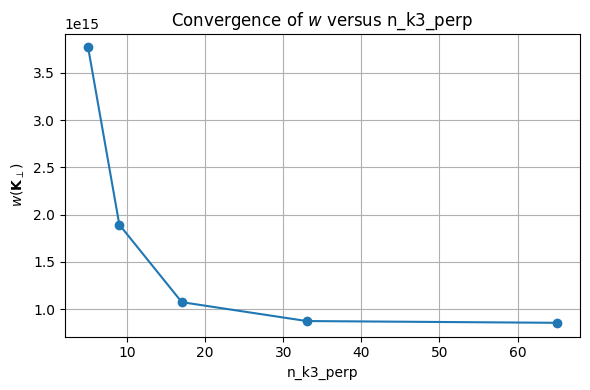

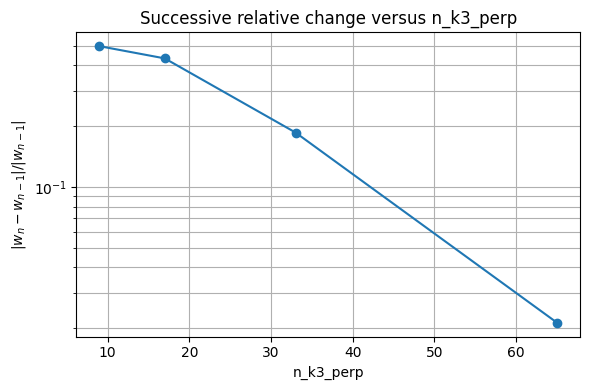

In [10]:
n_k3_perp_values = [5, 9, 17, 33, 65]
# n_k3_perp_values = [25]

n_values, w_values, time_values = scan_one_parameter(
    "n_k3_perp",
    n_k3_perp_values,
)

plot_scan("n_k3_perp", n_values, w_values)

n_phi =   2 | w = 1.472802656933e-03 | time = 0.70 s
n_phi =   3 | w = 1.472859184470e-03 | time = 1.06 s
n_phi =   4 | w = 1.472859184470e-03 | time = 1.44 s
n_phi =   5 | w = 1.472859184470e-03 | time = 1.78 s
n_phi =   6 | w = 1.472859184470e-03 | time = 2.10 s
n_phi =   7 | w = 1.472859184470e-03 | time = 2.47 s
n_phi =   8 | w = 1.472859184470e-03 | time = 2.81 s
n_phi =   9 | w = 1.472859184470e-03 | time = 3.18 s


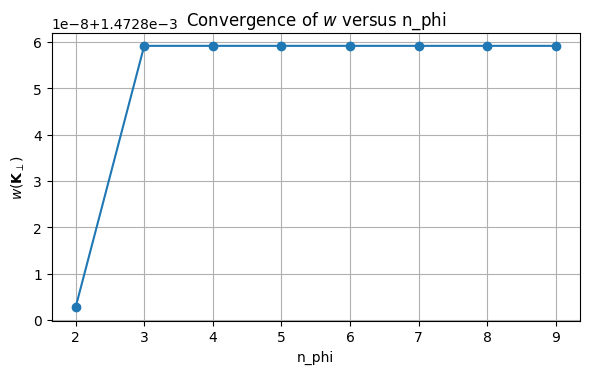

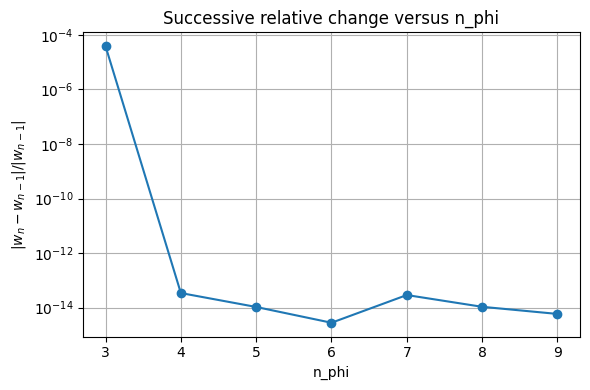

In [10]:
n_phi_values = range(2, 10)

n_values, w_values, time_values = scan_one_parameter(
    "n_phi",
    n_phi_values,
)

plot_scan("n_phi", n_values, w_values)

n_k3z =   5 | w = 1.472859641885e-03 | time = 0.70 s
n_k3z =   9 | w = 1.472859131616e-03 | time = 1.36 s
n_k3z =  17 | w = 1.472859217559e-03 | time = 2.36 s
n_k3z =  33 | w = 1.472859173858e-03 | time = 4.65 s
n_k3z =  65 | w = 1.472859257660e-03 | time = 8.99 s


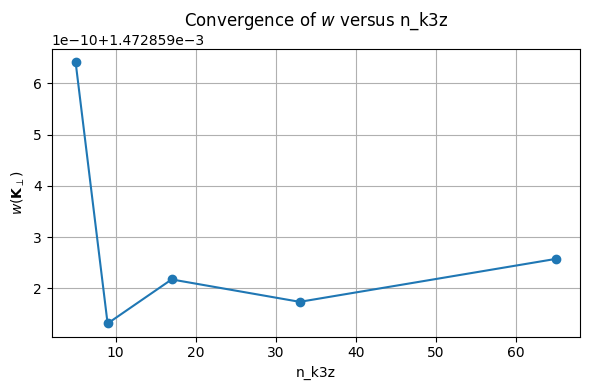

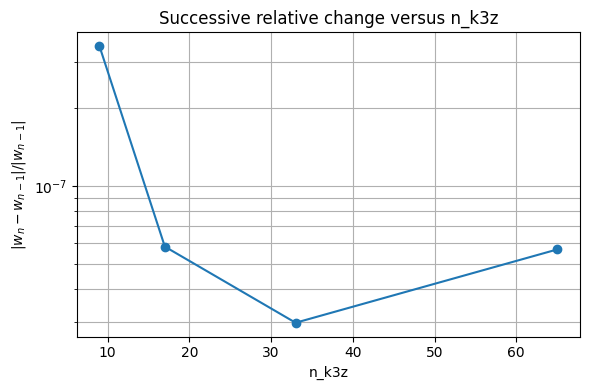

In [11]:
n_k3z_values = [5, 9, 17, 33, 65]

n_values, w_values, time_values = scan_one_parameter(
    "n_k3z",
    n_k3z_values,
)

plot_scan("n_k3z", n_values, w_values)

n_k4z =   5 | w = 1.472859641885e-03 | time = 0.70 s
n_k4z =   9 | w = 1.472859131616e-03 | time = 1.27 s
n_k4z =  17 | w = 1.472859217559e-03 | time = 2.40 s
n_k4z =  33 | w = 1.472859173858e-03 | time = 4.71 s
n_k4z =  65 | w = 1.472859257660e-03 | time = 9.09 s


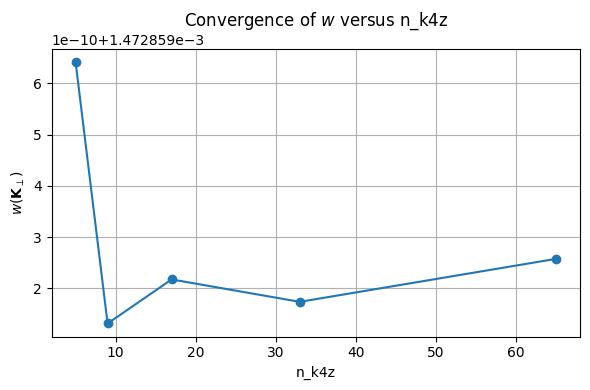

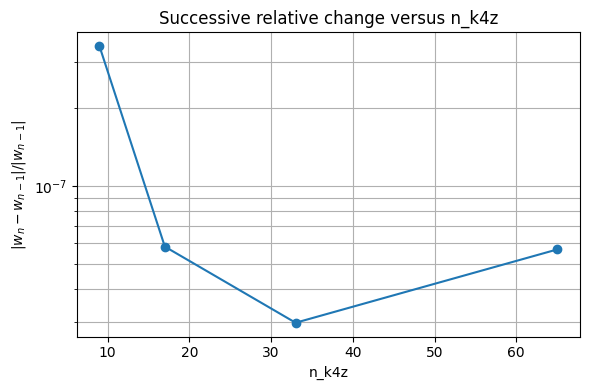

In [12]:
n_k4z_values = [5, 9, 17, 33, 65]

n_values, w_values, time_values = scan_one_parameter(
    "n_k4z",
    n_k4z_values,
)

plot_scan("n_k4z", n_values, w_values)

Impulse approximation

In [5]:
k3 = np.array([0.01, 0.0, 10.0], dtype=float)
k4 = np.array([-0.01, 1.0e-4, -10.0], dtype=float)

S0 = mv.S_impulse_closed_form(
    k3,
    k4,
    packet1,
    packet2,
    lam1=-0.5,
    lam2=0.5,
    lam3=-0.5,
    lam4=0.5,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
)

S1, details = mv.S_impulse_first_order(
    k3,
    k4,
    packet1,
    packet2,
    lam1=-0.5,
    lam2=0.5,
    lam3=-0.5,
    lam4=0.5,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    return_details=True,
    time_mode="resummed",
)

print("S0 =", S0)
print("S1 =", S1)
print("|S1 - S0| =", abs(S1 - S0))
print("|S0| =", abs(S0))
print("|S1| =", abs(S1))

if abs(S0) != 0.0:
    print("relative amplitude correction =", abs(S1 - S0) / abs(S0))
    print("relative probability correction =", abs(S1)**2 / abs(S0)**2 - 1.0)

print("I0 =", details["I0"])
print("I1 =", details["I1"])
print("I2 =", details["I2"])
print("time_step =", details["time_step"])

S0 = (-34.70873286285626-2.238399701936046j)
S1 = (-123.03658537117339-7.934748188320827j)
|S1 - S0| = 88.51134342449765
|S0| = 34.78083624887052
|S1| = 123.29217967336815
relative amplitude correction = 2.5448308025478252
relative probability correction = 11.565825418691853
I0 = (6.941988081762369e-33-1.0764279929925859e-31j)
I1 = (4.540252603684915e-40+2.4526956222647534e-41j)
I2 = (-7.486936862491653e-50+1.685329016014621e-48j)
time_step = 25679.987856224623


Heatmap: $k_{3z}$ and $k_{4z}$ distribution

beyond impulse approximation

K_perp_test = [ 0.     -0.0001] MeV
k3z range = (np.float64(9.99605074), np.float64(10.00394926)) MeV
k4z range = (np.float64(-10.0197463), np.float64(-9.9802537)) MeV
n_k3z_map = 41
n_k4z_map = 41
n_k3_perp = 9
n_phi = 16
S_function = S_function
row   1 /  41 completed | k4z = -1.001974630000e+01 MeV | row time = 2.85 s | total time = 2.85 s
row   2 /  41 completed | k4z = -1.001875898500e+01 MeV | row time = 2.98 s | total time = 5.83 s
row   3 /  41 completed | k4z = -1.001777167000e+01 MeV | row time = 2.83 s | total time = 8.67 s
row   4 /  41 completed | k4z = -1.001678435500e+01 MeV | row time = 2.98 s | total time = 11.65 s
row   5 /  41 completed | k4z = -1.001579704000e+01 MeV | row time = 2.72 s | total time = 14.37 s
row   6 /  41 completed | k4z = -1.001480972500e+01 MeV | row time = 2.74 s | total time = 17.11 s
row   7 /  41 completed | k4z = -1.001382241000e+01 MeV | row time = 2.61 s | total time = 19.72 s
row   8 /  41 completed | k4z = -1.001283509500e+01 MeV | row t

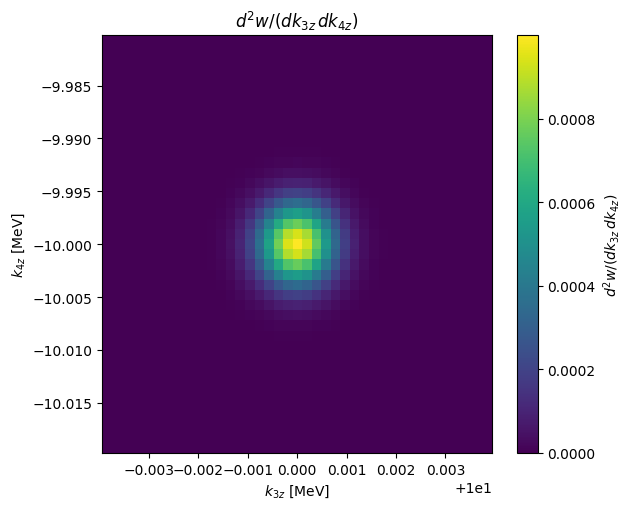

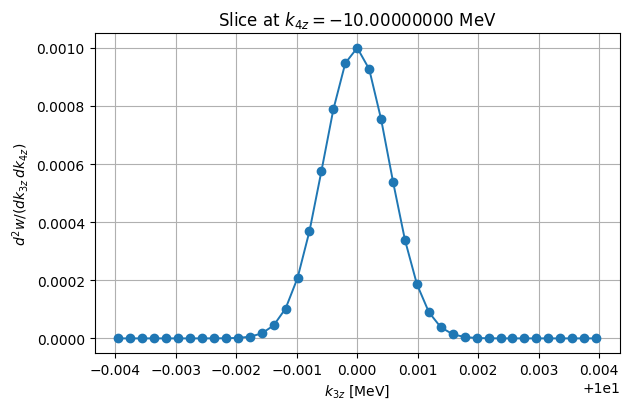

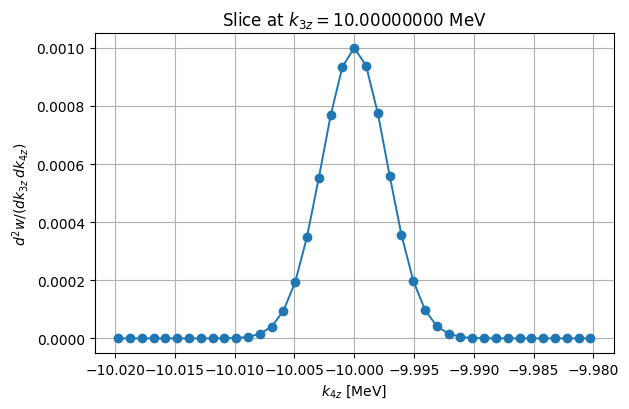

In [8]:
# Choose the S-matrix mode.
S_time_mode = "resummed"   # "resummed" or "expanded"

def S_function(
    k3,
    k4,
    packet1,
    packet2,
    *,
    lam1,
    lam2,
    lam3,
    lam4,
    impact_b,
    N1=None,
    N2=None,
    accuracy=None,
):
    return mv.S_impulse_first_order(
        k3,
        k4,
        packet1,
        packet2,
        lam1=lam1,
        lam2=lam2,
        lam3=lam3,
        lam4=lam4,
        impact_b=impact_b,
        N1=N1,
        N2=N2,
        accuracy=accuracy,
        time_mode=S_time_mode,
    )


# Total final transverse momentum K_perp = k3_perp + k4_perp.
K_perp_test = np.array([0.0, -1.0e-4], dtype=float)  # MeV

k3z_values = np.linspace(
    packet1.kbar_z - 100.0 * packet1.sigma_par,
    packet1.kbar_z + 100.0 * packet1.sigma_par,
    41,
)

k4z_values = np.linspace(
    packet2.kbar_z - 100.0 * packet2.sigma_par,
    packet2.kbar_z + 100.0 * packet2.sigma_par,
    41,
)

n_k3z_map = len(k3z_values)
n_k4z_map = len(k4z_values)

# Quadrature for the remaining transverse variables k3_perp and phi3.
# Start with moderate values because the full map can be expensive.
q_map = replace(
    quadrature,
    n_k3_perp=9,
    n_phi=16,
)

# ============================================================
# Helper functions
# ============================================================

def call_S(
    S_function,
    k3,
    k4,
    packet1,
    packet2,
    *,
    lam1,
    lam2,
    lam3,
    lam4,
    impact_b,
    N1,
    N2,
    accuracy=None,
):
    """Call an S-matrix function with compatibility for optional accuracy."""
    try:
        return S_function(
            k3,
            k4,
            packet1,
            packet2,
            lam1=lam1,
            lam2=lam2,
            lam3=lam3,
            lam4=lam4,
            impact_b=impact_b,
            N1=N1,
            N2=N2,
            accuracy=accuracy,
        )
    except TypeError:
        return S_function(
            k3,
            k4,
            packet1,
            packet2,
            lam1=lam1,
            lam2=lam2,
            lam3=lam3,
            lam4=lam4,
            impact_b=impact_b,
            N1=N1,
            N2=N2,
        )


def spin_averaged_s_abs2(
    S_function,
    k3,
    k4,
    packet1,
    packet2,
    *,
    impact_b,
    N1,
    N2,
    accuracy=None,
):
    """Return spin-averaged |S|^2 with averaging over initial helicities."""
    helicities = [-0.5, 0.5]
    total = 0.0

    for lam1 in helicities:
        for lam2 in helicities:
            for lam3 in helicities:
                for lam4 in helicities:
                    S = call_S(
                        S_function,
                        k3,
                        k4,
                        packet1,
                        packet2,
                        lam1=lam1,
                        lam2=lam2,
                        lam3=lam3,
                        lam4=lam4,
                        impact_b=impact_b,
                        N1=N1,
                        N2=N2,
                        accuracy=accuracy,
                    )

                    total += abs(S) ** 2

    return total / 4.0


def longitudinal_density_at_point(
    k3z,
    k4z,
    K_perp,
    packet1,
    packet2,
    quadrature,
    *,
    S_function,
    impact_b,
    N1,
    N2,
    accuracy=None,
):
    """
    Compute Z(k3z, k4z) such that

        w(K_perp) = integral dk3z dk4z Z(k3z, k4z).

    Here

        Z(k3z, k4z)
        = integral dk3_perp dphi3
          k3_perp |S|^2_avg / [(2pi)^6 4 E3 E4].
    """

    rho_nodes, rho_weights = mv.legendre_nodes_and_weights(
        quadrature.k3_perp_range,
        quadrature.n_k3_perp,
    )

    phi_nodes = np.linspace(
        0.0,
        2.0 * np.pi,
        quadrature.n_phi,
        endpoint=False,
    )

    phi_weight = 2.0 * np.pi / quadrature.n_phi

    total = 0.0

    for rho, w_rho in zip(rho_nodes, rho_weights):
        for phi in phi_nodes:
            k3 = np.array(
                [
                    rho * np.cos(phi),
                    rho * np.sin(phi),
                    k3z,
                ],
                dtype=float,
            )

            k4 = np.array(
                [
                    K_perp[0] - k3[0],
                    K_perp[1] - k3[1],
                    k4z,
                ],
                dtype=float,
            )

            E3 = mv.energy(k3)
            E4 = mv.energy(k4)

            s_abs2 = spin_averaged_s_abs2(
                S_function,
                k3,
                k4,
                packet1,
                packet2,
                impact_b=impact_b,
                N1=N1,
                N2=N2,
                accuracy=accuracy,
            )

            integrand = (
                rho
                * s_abs2
                / ((2.0 * np.pi) ** 6 * 4.0 * E3 * E4)
            )

            total += w_rho * phi_weight * integrand

    return total


def build_longitudinal_map(
    k3z_values,
    k4z_values,
    K_perp,
    packet1,
    packet2,
    quadrature,
    *,
    S_function,
    impact_b,
    N1,
    N2,
    accuracy=None,
):
    """Build the array Z[k4z_index, k3z_index]."""
    Z = np.zeros((len(k4z_values), len(k3z_values)), dtype=float)

    start_total = time.perf_counter()

    for i4, k4z in enumerate(k4z_values):
        start_row = time.perf_counter()

        for i3, k3z in enumerate(k3z_values):
            Z[i4, i3] = longitudinal_density_at_point(
                k3z,
                k4z,
                K_perp,
                packet1,
                packet2,
                quadrature,
                S_function=S_function,
                impact_b=impact_b,
                N1=N1,
                N2=N2,
                accuracy=accuracy,
            )

        elapsed_row = time.perf_counter() - start_row
        elapsed_total = time.perf_counter() - start_total

        print(
            f"row {i4 + 1:3d} / {len(k4z_values):3d} completed | "
            f"k4z = {k4z:.12e} MeV | "
            f"row time = {elapsed_row:.2f} s | "
            f"total time = {elapsed_total:.2f} s",
            flush=True,
        )

    return Z


# ============================================================
# Build the longitudinal map
# ============================================================

print("K_perp_test =", K_perp_test, "MeV")
print("k3z range =", (k3z_values[0], k3z_values[-1]), "MeV")
print("k4z range =", (k4z_values[0], k4z_values[-1]), "MeV")
print("n_k3z_map =", n_k3z_map)
print("n_k4z_map =", n_k4z_map)
print("n_k3_perp =", q_map.n_k3_perp)
print("n_phi =", q_map.n_phi)
print("S_function =", S_function.__name__)

Z_long = build_longitudinal_map(
    k3z_values,
    k4z_values,
    K_perp_test,
    packet1,
    packet2,
    q_map,
    S_function=S_function,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    accuracy=accuracy,
)

# ============================================================
# Numerical diagnostics
# ============================================================

print()
print("Z finite count =", np.isfinite(Z_long).sum(), "/", Z_long.size)
print("Z min =", np.nanmin(Z_long))
print("Z max =", np.nanmax(Z_long))
print("Z mean =", np.nanmean(Z_long))

if np.nanmean(Z_long) != 0.0:
    print(
        "relative range =",
        (np.nanmax(Z_long) - np.nanmin(Z_long)) / abs(np.nanmean(Z_long)),
    )

# ============================================================
# Linear map
# ============================================================

fig, ax = plt.subplots(figsize=(6.4, 5.2))

image = ax.imshow(
    Z_long,
    origin="lower",
    extent=[
        k3z_values[0],
        k3z_values[-1],
        k4z_values[0],
        k4z_values[-1],
    ],
    aspect="auto",
)

ax.set_xlabel(r"$k_{3z}$ [MeV]")
ax.set_ylabel(r"$k_{4z}$ [MeV]")
ax.set_title(r"$d^2w/(dk_{3z}\,dk_{4z})$")

cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$d^2w/(dk_{3z}\,dk_{4z})$")

fig.tight_layout()
plt.show()

# ============================================================
# Central slices
# ============================================================

i4_mid = len(k4z_values) // 2
i3_mid = len(k3z_values) // 2

fig, ax = plt.subplots(figsize=(6.4, 4.2))

ax.plot(
    k3z_values,
    Z_long[i4_mid, :],
    marker="o",
    linewidth=1.4,
)

ax.set_xlabel(r"$k_{3z}$ [MeV]")
ax.set_ylabel(r"$d^2w/(dk_{3z}\,dk_{4z})$")
ax.set_title(rf"Slice at $k_{{4z}}={k4z_values[i4_mid]:.8f}$ MeV")
ax.grid(True)

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.4, 4.2))

ax.plot(
    k4z_values,
    Z_long[:, i3_mid],
    marker="o",
    linewidth=1.4,
)

ax.set_xlabel(r"$k_{4z}$ [MeV]")
ax.set_ylabel(r"$d^2w/(dk_{3z}\,dk_{4z})$")
ax.set_title(rf"Slice at $k_{{3z}}={k3z_values[i3_mid]:.8f}$ MeV")
ax.grid(True)

fig.tight_layout()
plt.show()

impulse approximation

K_perp_test = [ 0.     -0.0001] MeV
k3z range = (np.float64(9.99605074), np.float64(10.00394926)) MeV
k4z range = (np.float64(-10.0197463), np.float64(-9.9802537)) MeV
n_k3z_map = 41
n_k4z_map = 41
n_k3_perp = 9
n_phi = 16
S_function = S_impulse_closed_form
row   1 /  41 completed | k4z = -1.001974630000e+01 MeV | row time = 1.00 s | total time = 1.00 s
row   2 /  41 completed | k4z = -1.001875898500e+01 MeV | row time = 0.91 s | total time = 1.91 s
row   3 /  41 completed | k4z = -1.001777167000e+01 MeV | row time = 0.90 s | total time = 2.81 s
row   4 /  41 completed | k4z = -1.001678435500e+01 MeV | row time = 0.94 s | total time = 3.76 s
row   5 /  41 completed | k4z = -1.001579704000e+01 MeV | row time = 0.90 s | total time = 4.66 s
row   6 /  41 completed | k4z = -1.001480972500e+01 MeV | row time = 0.89 s | total time = 5.55 s
row   7 /  41 completed | k4z = -1.001382241000e+01 MeV | row time = 0.84 s | total time = 6.39 s
row   8 /  41 completed | k4z = -1.001283509500e+01 MeV 

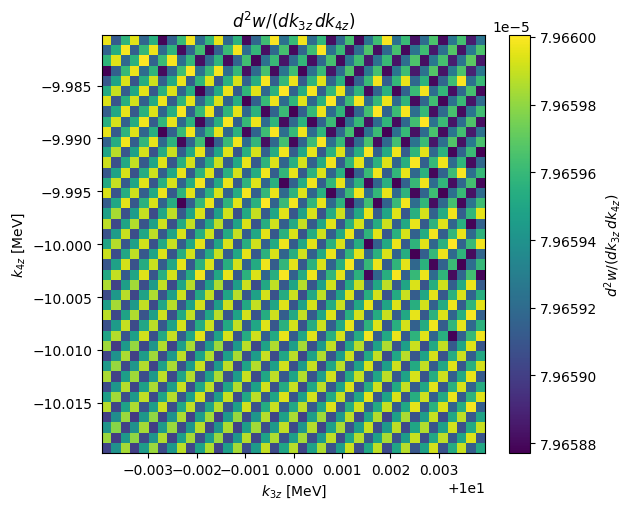

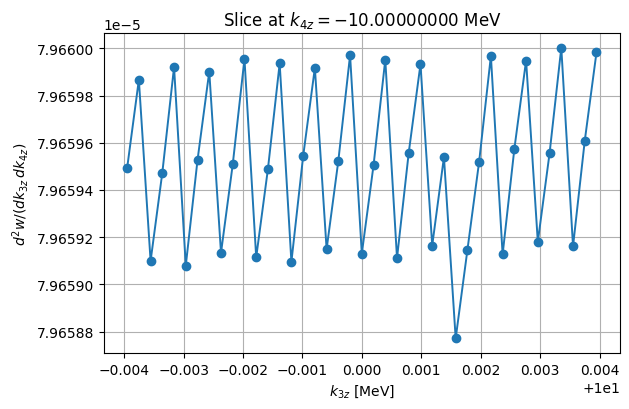

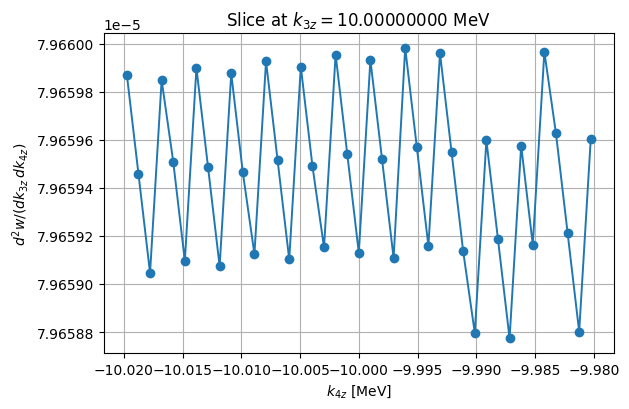

In [7]:
# Choose the S-matrix function.
S_function = mv.S_impulse_closed_form
# S_function = mv.S_impulse_first_order

# Total final transverse momentum K_perp = k3_perp + k4_perp.
K_perp_test = np.array([0.0, -1.0e-4], dtype=float)  # MeV

k3z_values = np.linspace(
    packet1.kbar_z - 100.0 * packet1.sigma_par,
    packet1.kbar_z + 100.0 * packet1.sigma_par,
    41,
)

k4z_values = np.linspace(
    packet2.kbar_z - 100.0 * packet2.sigma_par,
    packet2.kbar_z + 100.0 * packet2.sigma_par,
    41,
)

n_k3z_map = len(k3z_values)
n_k4z_map = len(k4z_values)

# Quadrature for the remaining transverse variables k3_perp and phi3.
# Start with moderate values because the full map can be expensive.
q_map = replace(
    quadrature,
    n_k3_perp=9,
    n_phi=16,
)

# ============================================================
# Helper functions
# ============================================================

def call_S(
    S_function,
    k3,
    k4,
    packet1,
    packet2,
    *,
    lam1,
    lam2,
    lam3,
    lam4,
    impact_b,
    N1,
    N2,
    accuracy=None,
):
    """Call an S-matrix function with compatibility for optional accuracy."""
    try:
        return S_function(
            k3,
            k4,
            packet1,
            packet2,
            lam1=lam1,
            lam2=lam2,
            lam3=lam3,
            lam4=lam4,
            impact_b=impact_b,
            N1=N1,
            N2=N2,
            accuracy=accuracy,
        )
    except TypeError:
        return S_function(
            k3,
            k4,
            packet1,
            packet2,
            lam1=lam1,
            lam2=lam2,
            lam3=lam3,
            lam4=lam4,
            impact_b=impact_b,
            N1=N1,
            N2=N2,
        )


def spin_averaged_s_abs2(
    S_function,
    k3,
    k4,
    packet1,
    packet2,
    *,
    impact_b,
    N1,
    N2,
    accuracy=None,
):
    """Return spin-averaged |S|^2 with averaging over initial helicities."""
    helicities = [-0.5, 0.5]
    total = 0.0

    for lam1 in helicities:
        for lam2 in helicities:
            for lam3 in helicities:
                for lam4 in helicities:
                    S = call_S(
                        S_function,
                        k3,
                        k4,
                        packet1,
                        packet2,
                        lam1=lam1,
                        lam2=lam2,
                        lam3=lam3,
                        lam4=lam4,
                        impact_b=impact_b,
                        N1=N1,
                        N2=N2,
                        accuracy=accuracy,
                    )

                    total += abs(S) ** 2

    return total / 4.0


def longitudinal_density_at_point(
    k3z,
    k4z,
    K_perp,
    packet1,
    packet2,
    quadrature,
    *,
    S_function,
    impact_b,
    N1,
    N2,
    accuracy=None,
):
    """
    Compute Z(k3z, k4z) such that

        w(K_perp) = integral dk3z dk4z Z(k3z, k4z).

    Here

        Z(k3z, k4z)
        = integral dk3_perp dphi3
          k3_perp |S|^2_avg / [(2pi)^6 4 E3 E4].
    """

    rho_nodes, rho_weights = mv.legendre_nodes_and_weights(
        quadrature.k3_perp_range,
        quadrature.n_k3_perp,
    )

    phi_nodes = np.linspace(
        0.0,
        2.0 * np.pi,
        quadrature.n_phi,
        endpoint=False,
    )

    phi_weight = 2.0 * np.pi / quadrature.n_phi

    total = 0.0

    for rho, w_rho in zip(rho_nodes, rho_weights):
        for phi in phi_nodes:
            k3 = np.array(
                [
                    rho * np.cos(phi),
                    rho * np.sin(phi),
                    k3z,
                ],
                dtype=float,
            )

            k4 = np.array(
                [
                    K_perp[0] - k3[0],
                    K_perp[1] - k3[1],
                    k4z,
                ],
                dtype=float,
            )

            E3 = mv.energy(k3)
            E4 = mv.energy(k4)

            s_abs2 = spin_averaged_s_abs2(
                S_function,
                k3,
                k4,
                packet1,
                packet2,
                impact_b=impact_b,
                N1=N1,
                N2=N2,
                accuracy=accuracy,
            )

            integrand = (
                rho
                * s_abs2
                / ((2.0 * np.pi) ** 6 * 4.0 * E3 * E4)
            )

            total += w_rho * phi_weight * integrand

    return total


def build_longitudinal_map(
    k3z_values,
    k4z_values,
    K_perp,
    packet1,
    packet2,
    quadrature,
    *,
    S_function,
    impact_b,
    N1,
    N2,
    accuracy=None,
):
    """Build the array Z[k4z_index, k3z_index]."""
    Z = np.zeros((len(k4z_values), len(k3z_values)), dtype=float)

    start_total = time.perf_counter()

    for i4, k4z in enumerate(k4z_values):
        start_row = time.perf_counter()

        for i3, k3z in enumerate(k3z_values):
            Z[i4, i3] = longitudinal_density_at_point(
                k3z,
                k4z,
                K_perp,
                packet1,
                packet2,
                quadrature,
                S_function=S_function,
                impact_b=impact_b,
                N1=N1,
                N2=N2,
                accuracy=accuracy,
            )

        elapsed_row = time.perf_counter() - start_row
        elapsed_total = time.perf_counter() - start_total

        print(
            f"row {i4 + 1:3d} / {len(k4z_values):3d} completed | "
            f"k4z = {k4z:.12e} MeV | "
            f"row time = {elapsed_row:.2f} s | "
            f"total time = {elapsed_total:.2f} s",
            flush=True,
        )

    return Z


# ============================================================
# Build the longitudinal map
# ============================================================

print("K_perp_test =", K_perp_test, "MeV")
print("k3z range =", (k3z_values[0], k3z_values[-1]), "MeV")
print("k4z range =", (k4z_values[0], k4z_values[-1]), "MeV")
print("n_k3z_map =", n_k3z_map)
print("n_k4z_map =", n_k4z_map)
print("n_k3_perp =", q_map.n_k3_perp)
print("n_phi =", q_map.n_phi)
print("S_function =", S_function.__name__)

Z_long = build_longitudinal_map(
    k3z_values,
    k4z_values,
    K_perp_test,
    packet1,
    packet2,
    q_map,
    S_function=S_function,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    accuracy=accuracy,
)

# ============================================================
# Numerical diagnostics
# ============================================================

print()
print("Z finite count =", np.isfinite(Z_long).sum(), "/", Z_long.size)
print("Z min =", np.nanmin(Z_long))
print("Z max =", np.nanmax(Z_long))
print("Z mean =", np.nanmean(Z_long))

if np.nanmean(Z_long) != 0.0:
    print(
        "relative range =",
        (np.nanmax(Z_long) - np.nanmin(Z_long)) / abs(np.nanmean(Z_long)),
    )

# ============================================================
# Linear map
# ============================================================

fig, ax = plt.subplots(figsize=(6.4, 5.2))

image = ax.imshow(
    Z_long,
    origin="lower",
    extent=[
        k3z_values[0],
        k3z_values[-1],
        k4z_values[0],
        k4z_values[-1],
    ],
    aspect="auto",
)

ax.set_xlabel(r"$k_{3z}$ [MeV]")
ax.set_ylabel(r"$k_{4z}$ [MeV]")
ax.set_title(r"$d^2w/(dk_{3z}\,dk_{4z})$")

cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$d^2w/(dk_{3z}\,dk_{4z})$")

fig.tight_layout()
plt.show()

# ============================================================
# Central slices
# ============================================================

i4_mid = len(k4z_values) // 2
i3_mid = len(k3z_values) // 2

fig, ax = plt.subplots(figsize=(6.4, 4.2))

ax.plot(
    k3z_values,
    Z_long[i4_mid, :],
    marker="o",
    linewidth=1.4,
)

ax.set_xlabel(r"$k_{3z}$ [MeV]")
ax.set_ylabel(r"$d^2w/(dk_{3z}\,dk_{4z})$")
ax.set_title(rf"Slice at $k_{{4z}}={k4z_values[i4_mid]:.8f}$ MeV")
ax.grid(True)

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.4, 4.2))

ax.plot(
    k4z_values,
    Z_long[:, i3_mid],
    marker="o",
    linewidth=1.4,
)

ax.set_xlabel(r"$k_{4z}$ [MeV]")
ax.set_ylabel(r"$d^2w/(dk_{3z}\,dk_{4z})$")
ax.set_title(rf"Slice at $k_{{3z}}={k3z_values[i3_mid]:.8f}$ MeV")
ax.grid(True)

fig.tight_layout()
plt.show()

## 3. Incoming packets and normalization

`LGPacket` contains only physical packet parameters. Normalization constants are computed explicitly by `normalization_constant`.

In [4]:
packet1 = mv.LGPacket(
    ell=1,
    sigma_perp=0.18,
    sigma_par=0.35,
    kbar_z=20.0,
)

packet2 = mv.LGPacket(
    ell=-1,
    sigma_perp=0.18,
    sigma_par=0.35,
    kbar_z=-20.0,
)

N1 = mv.normalization_constant(packet1, accuracy=accuracy)
N2 = mv.normalization_constant(packet2, accuracy=accuracy)

print("packet1 =", packet1)
print("packet2 =", packet2)
print("N1 =", N1)
print("N2 =", N2)

packet1 = LGPacket(ell=1, sigma_perp=0.18, sigma_par=0.35, kbar_z=20.0)
packet2 = LGPacket(ell=-1, sigma_perp=0.18, sigma_par=0.35, kbar_z=-20.0)
N1 = 64.5323735338619
N2 = 64.5323735338619


## 4. Final momenta, helicities, and impact parameter

All momenta are in MeV. The impact parameter is in MeV$^{-1}$. In the current convention the impact phase is applied only to the second incoming packet.

In [5]:
k3 = np.array([0.80, 0.10, 19.70])
k4 = np.array([-0.55, -0.08, -19.60])

impact_b = np.array([0.30, 0.00])

lam1 = 0.5
lam2 = 0.5
lam3 = 0.5
lam4 = 0.5

## 5. Closed impulse S-matrix

This is the main fast expression. It uses the analytic transverse integral.

In [6]:
S_closed = mv.S_impulse_closed_form(
    k3,
    k4,
    packet1,
    packet2,
    lam1=lam1,
    lam2=lam2,
    lam3=lam3,
    lam4=lam4,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    accuracy=accuracy,
)

S_closed

(0.00015242280451623416+0.01574217901924485j)

## 6. Numerical transverse check

This is slower. It replaces the analytic transverse integral by a direct numerical transverse integration, while keeping the same external prefactors. Use it as a check, not as the main production method.

In [7]:
S_numeric_transverse = mv.S_impulse_numeric_transverse_quad(
    k3,
    k4,
    packet1,
    packet2,
    lam1=lam1,
    lam2=lam2,
    lam3=lam3,
    lam4=lam4,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    n_phi=32,
    accuracy=accuracy,
)

print("S_closed             =", S_closed)
print("S_numeric_transverse =", S_numeric_transverse)
print("relative error       =", mv.relative_error(S_numeric_transverse, S_closed))

S_closed             = (0.00015242280451623416+0.01574217901924485j)
S_numeric_transverse = (0.0001524228045191255+0.015742179019263867j)
relative error       = 1.2217935776812517e-12


# Differential probability $w$ plot

In [ ]:
6.582119569 * 10**(-16) * 3 * 10**8 * 10**9 * 10**(-6) #hbar * c

0.00019746358706999997

## $b = 5$ nm

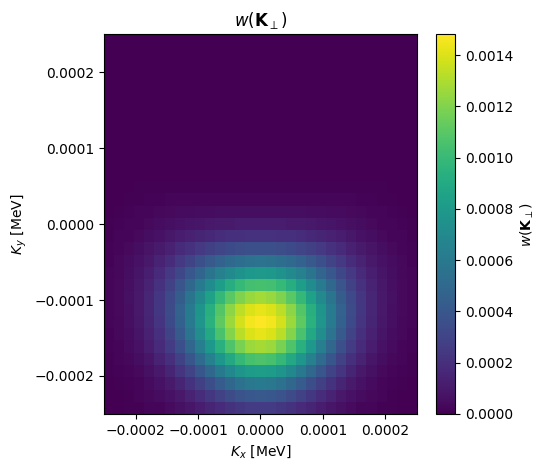

In [ ]:
sigma1_perp = spatial_width_nm_to_momentum_mev(10.0)
sigma2_perp = spatial_width_nm_to_momentum_mev(2.0)
sigma1_par = spatial_width_nm_to_momentum_mev(5.0)
sigma2_par = spatial_width_nm_to_momentum_mev(1.0)

impact_b = np.array([5.0 * NM_TO_MEV_INV, 0.0], dtype=float)

packet1 = mv.LGPacket(
    ell=5,
    sigma_perp=sigma1_perp,
    sigma_par=sigma1_par,
    kbar_z=10.0,
)

packet2 = mv.LGPacket(
    ell=0,
    sigma_perp=sigma2_perp,
    sigma_par=sigma2_par,
    kbar_z=-10.0,
)

N1 = mv.normalization_constant(packet1, accuracy=accuracy)
N2 = mv.normalization_constant(packet2, accuracy=accuracy)

quadrature = mv.ProbabilityQuadrature(
    k3_perp_range=(0.010, 0.050),
    k3z_range=(8.0, 12.0),
    k4z_range=(-12.0, -8.0),
    n_k3_perp=10,
    n_phi=24,
    n_k3z=10,
    n_k4z=10,
)

Kx_values = np.linspace(-0.00025, 0.00025, 31)
Ky_values = np.linspace(-0.00025, 0.00025, 31)

W = mv.diff_probability_grid(
    Kx_values,
    Ky_values,
    packet1,
    packet2,
    quadrature,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    accuracy=accuracy,
)

fig, ax = plt.subplots(figsize=(5.5, 4.8))

image = ax.imshow(
    W,
    origin="lower",
    extent=[
        Kx_values[0],
        Kx_values[-1],
        Ky_values[0],
        Ky_values[-1],
    ],
    aspect="auto",
)

ax.set_xlabel(r"$K_x$ [MeV]")
ax.set_ylabel(r"$K_y$ [MeV]")
ax.set_title(r"$w(\mathbf{K}_{\perp})$")

cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$w(\mathbf{K}_{\perp})$")

fig.tight_layout()
plt.show()


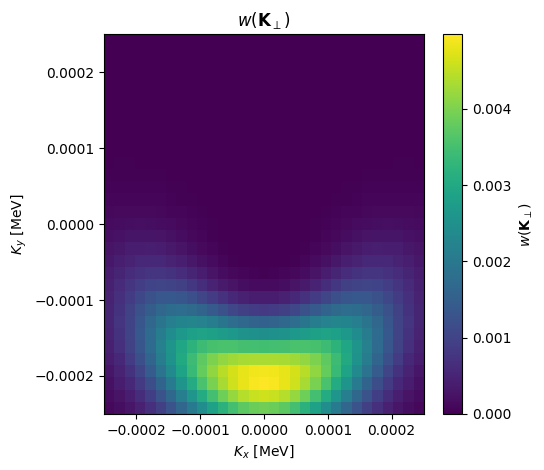

In [3]:
HBARC_MEV_NM = 1.97463e-4 #MeV * nm
NM_TO_MEV_INV = 1.0 / HBARC_MEV_NM 

def spatial_width_nm_to_momentum_mev(width_nm: float) -> float:
    return HBARC_MEV_NM / width_nm


sigma1_perp = spatial_width_nm_to_momentum_mev(10.0)
sigma2_perp = spatial_width_nm_to_momentum_mev(2.0)
sigma1_par = spatial_width_nm_to_momentum_mev(5.0)
sigma2_par = spatial_width_nm_to_momentum_mev(1.0)

impact_b = np.array([5.0 * NM_TO_MEV_INV, 0.0], dtype=float)

packet1 = mv.LGPacket(
    ell=5,
    sigma_perp=sigma1_perp,
    sigma_par=sigma1_par,
    kbar_z=10.0,
)

packet2 = mv.LGPacket(
    ell=2,
    sigma_perp=sigma2_perp,
    sigma_par=sigma2_par,
    kbar_z=-10.0,
)

N1 = mv.normalization_constant(packet1, accuracy=accuracy)
N2 = mv.normalization_constant(packet2, accuracy=accuracy)

quadrature = mv.ProbabilityQuadrature(
    k3_perp_range=(0.010, 0.050),
    k3z_range=(8.0, 12.0),
    k4z_range=(-12.0, -8.0),
    n_k3_perp=10,
    n_phi=24,
    n_k3z=10,
    n_k4z=10,
)

Kx_values = np.linspace(-0.00025, 0.00025, 31)
Ky_values = np.linspace(-0.00025, 0.00025, 31)

W = mv.diff_probability_grid(
    Kx_values,
    Ky_values,
    packet1,
    packet2,
    quadrature,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    accuracy=accuracy,
)

fig, ax = plt.subplots(figsize=(5.5, 4.8))

image = ax.imshow(
    W,
    origin="lower",
    extent=[
        Kx_values[0],
        Kx_values[-1],
        Ky_values[0],
        Ky_values[-1],
    ],
    aspect="auto",
)

ax.set_xlabel(r"$K_x$ [MeV]")
ax.set_ylabel(r"$K_y$ [MeV]")
ax.set_title(r"$w(\mathbf{K}_{\perp})$")

cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$w(\mathbf{K}_{\perp})$")

fig.tight_layout()
plt.show()

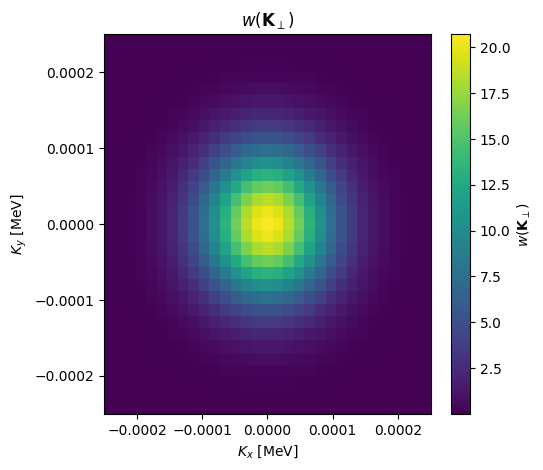

In [4]:
HBARC_MEV_NM = 1.97463e-4 #MeV * nm
NM_TO_MEV_INV = 1.0 / HBARC_MEV_NM 

def spatial_width_nm_to_momentum_mev(width_nm: float) -> float:
    return HBARC_MEV_NM / width_nm


sigma1_perp = spatial_width_nm_to_momentum_mev(10.0)
sigma2_perp = spatial_width_nm_to_momentum_mev(2.0)
sigma1_par = spatial_width_nm_to_momentum_mev(5.0)
sigma2_par = spatial_width_nm_to_momentum_mev(1.0)

impact_b = np.array([5.0 * NM_TO_MEV_INV, 0.0], dtype=float)

packet1 = mv.LGPacket(
    ell=0,
    sigma_perp=sigma1_perp,
    sigma_par=sigma1_par,
    kbar_z=10.0,
)

packet2 = mv.LGPacket(
    ell=0,
    sigma_perp=sigma2_perp,
    sigma_par=sigma2_par,
    kbar_z=-10.0,
)

N1 = mv.normalization_constant(packet1, accuracy=accuracy)
N2 = mv.normalization_constant(packet2, accuracy=accuracy)

quadrature = mv.ProbabilityQuadrature(
    k3_perp_range=(0.010, 0.050),
    k3z_range=(8.0, 12.0),
    k4z_range=(-12.0, -8.0),
    n_k3_perp=10,
    n_phi=24,
    n_k3z=10,
    n_k4z=10,
)

Kx_values = np.linspace(-0.00025, 0.00025, 31)
Ky_values = np.linspace(-0.00025, 0.00025, 31)

W = mv.diff_probability_grid(
    Kx_values,
    Ky_values,
    packet1,
    packet2,
    quadrature,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    accuracy=accuracy,
)

fig, ax = plt.subplots(figsize=(5.5, 4.8))

image = ax.imshow(
    W,
    origin="lower",
    extent=[
        Kx_values[0],
        Kx_values[-1],
        Ky_values[0],
        Ky_values[-1],
    ],
    aspect="auto",
)

ax.set_xlabel(r"$K_x$ [MeV]")
ax.set_ylabel(r"$K_y$ [MeV]")
ax.set_title(r"$w(\mathbf{K}_{\perp})$")

cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$w(\mathbf{K}_{\perp})$")

fig.tight_layout()
plt.show()

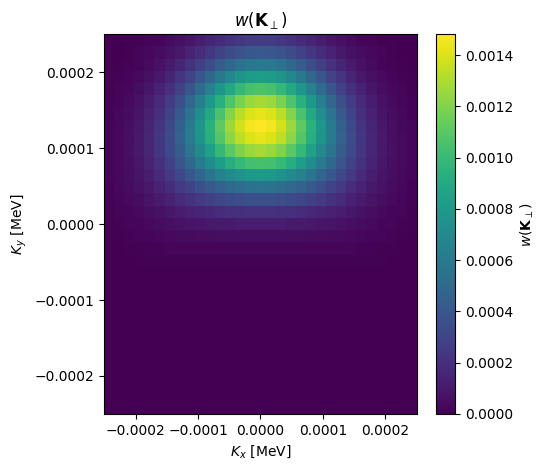

In [5]:
HBARC_MEV_NM = 1.97463e-4 #MeV * nm
NM_TO_MEV_INV = 1.0 / HBARC_MEV_NM 

def spatial_width_nm_to_momentum_mev(width_nm: float) -> float:
    return HBARC_MEV_NM / width_nm


sigma1_perp = spatial_width_nm_to_momentum_mev(10.0)
sigma2_perp = spatial_width_nm_to_momentum_mev(2.0)
sigma1_par = spatial_width_nm_to_momentum_mev(5.0)
sigma2_par = spatial_width_nm_to_momentum_mev(1.0)

impact_b = np.array([5.0 * NM_TO_MEV_INV, 0.0], dtype=float)

packet1 = mv.LGPacket(
    ell=-5,
    sigma_perp=sigma1_perp,
    sigma_par=sigma1_par,
    kbar_z=10.0,
)

packet2 = mv.LGPacket(
    ell=0,
    sigma_perp=sigma2_perp,
    sigma_par=sigma2_par,
    kbar_z=-10.0,
)

N1 = mv.normalization_constant(packet1, accuracy=accuracy)
N2 = mv.normalization_constant(packet2, accuracy=accuracy)

quadrature = mv.ProbabilityQuadrature(
    k3_perp_range=(0.010, 0.050),
    k3z_range=(8.0, 12.0),
    k4z_range=(-12.0, -8.0),
    n_k3_perp=10,
    n_phi=24,
    n_k3z=10,
    n_k4z=10,
)

Kx_values = np.linspace(-0.00025, 0.00025, 31)
Ky_values = np.linspace(-0.00025, 0.00025, 31)

W = mv.diff_probability_grid(
    Kx_values,
    Ky_values,
    packet1,
    packet2,
    quadrature,
    impact_b=impact_b,
    N1=N1,
    N2=N2,
    accuracy=accuracy,
)

fig, ax = plt.subplots(figsize=(5.5, 4.8))

image = ax.imshow(
    W,
    origin="lower",
    extent=[
        Kx_values[0],
        Kx_values[-1],
        Ky_values[0],
        Ky_values[-1],
    ],
    aspect="auto",
)

ax.set_xlabel(r"$K_x$ [MeV]")
ax.set_ylabel(r"$K_y$ [MeV]")
ax.set_title(r"$w(\mathbf{K}_{\perp})$")

cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$w(\mathbf{K}_{\perp})$")

fig.tight_layout()
plt.show()

# Average $\langle K_y \rangle$

Integrated 1 out of 40 points: b_x = 0.000 nm, <Ky> = -1.017972e-13 eV
Integrated 2 out of 40 points: b_x = 0.167 nm, <Ky> = 4.026816e+01 eV
Integrated 3 out of 40 points: b_x = 0.333 nm, <Ky> = 7.586473e+01 eV
Integrated 4 out of 40 points: b_x = 0.500 nm, <Ky> = 1.041034e+02 eV
Integrated 5 out of 40 points: b_x = 0.667 nm, <Ky> = 1.246866e+02 eV
Integrated 6 out of 40 points: b_x = 0.833 nm, <Ky> = 1.387985e+02 eV
Integrated 7 out of 40 points: b_x = 1.000 nm, <Ky> = 1.480506e+02 eV
Integrated 8 out of 40 points: b_x = 1.167 nm, <Ky> = 1.538811e+02 eV
Integrated 9 out of 40 points: b_x = 1.333 nm, <Ky> = 1.573728e+02 eV
Integrated 10 out of 40 points: b_x = 1.500 nm, <Ky> = 1.592762e+02 eV
Integrated 11 out of 40 points: b_x = 1.667 nm, <Ky> = 1.600926e+02 eV
Integrated 12 out of 40 points: b_x = 1.833 nm, <Ky> = 1.601532e+02 eV
Integrated 13 out of 40 points: b_x = 2.000 nm, <Ky> = 1.596784e+02 eV
Integrated 14 out of 40 points: b_x = 2.167 nm, <Ky> = 1.588168e+02 eV
Integrated 15 

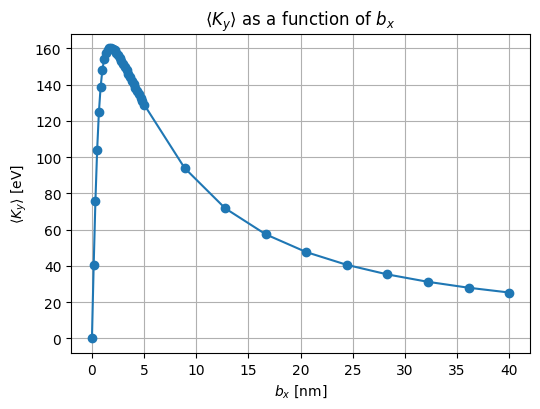

In [4]:
HBARC_MEV_NM = 1.97463e-4 #MeV * nm
NM_TO_MEV_INV = 1.0 / HBARC_MEV_NM 

def spatial_width_nm_to_momentum_mev(width_nm: float) -> float:
    return HBARC_MEV_NM / width_nm


sigma1_perp = spatial_width_nm_to_momentum_mev(10.0)
sigma2_perp = spatial_width_nm_to_momentum_mev(2.0)
sigma1_par = spatial_width_nm_to_momentum_mev(5.0)
sigma2_par = spatial_width_nm_to_momentum_mev(1.0)

impact_b = np.array([5.0 * NM_TO_MEV_INV, 0.0], dtype=float)

packet1 = mv.LGPacket(
    ell=-5,
    sigma_perp=sigma1_perp,
    sigma_par=sigma1_par,
    kbar_z=10.0,
)

packet2 = mv.LGPacket(
    ell=0,
    sigma_perp=sigma2_perp,
    sigma_par=sigma2_par,
    kbar_z=-10.0,
)

N1 = mv.normalization_constant(packet1, accuracy=accuracy)
N2 = mv.normalization_constant(packet2, accuracy=accuracy)

quadrature = mv.ProbabilityQuadrature(
    k3_perp_range=(0.010, 0.050),
    k3z_range=(
        10.0 - 10.0 * sigma1_par,
        10.0 + 10.0 * sigma1_par,
    ),
    k4z_range=(
        -10.0 - 10.0 * sigma2_par,
        -10.0 + 10.0 * sigma2_par,
    ),
    n_k3_perp=10,
    n_phi=24,
    n_k3z=10,
    n_k4z=10,

    # This is total final transverse momentum K_perp.
    # The relevant scale is eV, i.e. 1e-4 MeV.
    K_perp_range=(0.0, 3.0e-4),
    n_K_perp=10,
    n_K_phi=24,
)

b_x_nm = np.concatenate([
    np.linspace(0.0, 5.0, 30, endpoint=False),
    np.linspace(5.0, 40.0, 10),
])

average = []

for counter, b_nm in enumerate(b_x_nm, start=1):
    Ky_value = mv.Ky_average(
        packet1,
        packet2,
        quadrature,
        impact_b=np.array([b_nm * NM_TO_MEV_INV, 0.0], dtype=float),
        N1=N1,
        N2=N2,
        accuracy=accuracy,
    )

    average.append(Ky_value)

    print(
        f"Integrated {counter} out of {len(b_x_nm)} points: "
        f"b_x = {b_nm:.3f} nm, "
        f"<Ky> = {Ky_value * 1.0e6:.6e} eV",
        flush=True,
    )

average = np.array(average, dtype=float)

fig, ax = plt.subplots(figsize=(5.5, 4.2))

ax.plot(
    b_x_nm,
    average * 1.0e6,
    marker="o",
    linewidth=1.5,
)

ax.set_xlabel(r"$b_x$ [nm]")
ax.set_ylabel(r"$\langle K_y\rangle$ [eV]")
ax.set_title(r"$\langle K_y\rangle$ as a function of $b_x$")
ax.grid(True)

fig.tight_layout()
plt.show()